# Notebook 5 — Experiment 3: Hidden State as Classifier

## Core Idea

Train an LSTM on **all subjects** (NormCog + Demented) to predict next-TR network activations.
Then extract the **hidden state** at the last time step for every window of every test subject,
average them per subject → one 64-dimensional vector per person.

Finally, train simple classifiers (Logistic Regression, SVM, Random Forest) on those vectors
to predict **NormCog vs Demented** — using only the LSTM's internal representation.

**Key question:** Does the LSTM's hidden state implicitly capture clinical differences
even though it was never shown the diagnosis during training?

## Structure
1. Imports and configuration
2. Data loading and clinical metadata
3. Subject-level split (stratified, 70/15/15)
4. Dataset and DataLoaders
5. LSTM model definition and training
6. Training curves
7. Test evaluation (AUROC, Hamming, per-network metrics)
8. Extract hidden states for all test subjects
9. Aggregate hidden states per subject
10. Baseline: raw activation rates (no LSTM)
11. Classifier training + 5-fold cross-validation (LR, SVM, RF)
12. Classification results plot
13. ROC curves
14. Confusion matrices
15. PCA + t-SNE of the hidden space
16. Most discriminative hidden dimensions
17. Final summary

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy import stats

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    confusion_matrix, hamming_loss,
    f1_score, average_precision_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 34
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Network names ─────────────────────────────────────────────────────────────
NETWORK_NAMES = [
    'Visual', 'Somatomotor', 'Dorsal_Attention',
    'Ventral_Attention', 'Limbic', 'Frontoparietal', 'Default_Mode'
]
N_NETWORKS = len(NETWORK_NAMES)

Using device: cuda


## 2. Data loading

In [2]:
DATASET_DIR   = Path('model_dataset_Z15_W20')
METADATA_PATH = Path('OASIS3_metadata_clean.csv')

X_all       = np.load(DATASET_DIR / 'X.npy')
y_all       = np.load(DATASET_DIR / 'y.npy')
sample_meta = pd.read_csv(DATASET_DIR / 'sample_metadata.csv')
clinical    = pd.read_csv(METADATA_PATH)

# ── Merge clinical metadata ───────────────────────────────────────────────────
clinical['subject'] = 'sub-' + clinical['Subject_ID'].astype(str)
sample_meta = sample_meta.merge(
    clinical[['subject', 'DEMENTED', 'NORMCOG', 'Age']],
    on='subject', how='left'
)
sample_meta['group'] = 'Unknown'
sample_meta.loc[sample_meta['DEMENTED'] == 1, 'group'] = 'Demented'
sample_meta.loc[sample_meta['NORMCOG']  == 1, 'group'] = 'NormCog'

print(f'X shape : {X_all.shape}')
print(f'y shape : {y_all.shape}')
print('\nSample distribution by group:')
print(sample_meta['group'].value_counts())

X shape : (115115, 20, 7)
y shape : (115115, 7)

Sample distribution by group:
group
NormCog     73691
Demented    41424
Name: count, dtype: int64


## 3. Subject-level split (stratified 70 / 15 / 15)

The split is done at **subject level** — all windows from the same subject
stay in the same fold. This prevents data leakage.
The LSTM is trained on **all groups** (NormCog + Demented).

In [3]:
# ── All unique subjects with group label ─────────────────────────────────────
# Al remover train_test_split, respetamos el orden secuencial nativo de la lista
subject_groups = (
    sample_meta[['subject', 'group']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f'Unique subjects: {len(subject_groups)}')
print(subject_groups['group'].value_counts())

# ── Sequential Split: 70% train / 15% val / 15% test ────────────────────────
subjects_list = subject_groups['subject'].tolist()
n_subjects = len(subjects_list)

# Calculamos los puntos de corte exactos en la lista ordenada de sujetos
train_end = int(n_subjects * 0.70)          # Fin del primer 70%
val_end   = int(n_subjects * 0.85)          # Fin del siguiente 15% (70% + 15%)

# Hacemos los cortes limpios por posición (Slices secuenciales de listas)
train_subjects = subjects_list[:train_end]
val_subjects   = subjects_list[train_end:val_end]
test_subjects  = subjects_list[val_end:]

print(f'\nSubjects in train : {len(train_subjects)}')
print(f'Subjects in val   : {len(val_subjects)}')
print(f'Subjects in test  : {len(test_subjects)}')

# ── Sample indices per split ─────────────────────────────────────────────────
# Mapeamos los identificadores de sujetos a los índices de las ventanas (muestras)
train_idx = sample_meta[sample_meta['subject'].isin(train_subjects)].index.values
val_idx   = sample_meta[sample_meta['subject'].isin(val_subjects)].index.values
test_idx  = sample_meta[sample_meta['subject'].isin(test_subjects)].index.values

print(f'\nSamples in train : {len(train_idx)}')
print(f'Samples in val   : {len(val_idx)}')
print(f'Samples in test  : {len(test_idx)}')

# ── Integrity Check: Verificar que no haya solapamiento de ventanas ──────────
assert len(set(train_idx) & set(val_idx))  == 0, '¡Fuga de datos entre Train y Val!'
assert len(set(train_idx) & set(test_idx)) == 0, '¡Fuga de datos entre Train y Test!'
assert len(set(val_idx)   & set(test_idx)) == 0, '¡Fuga de datos entre Val y Test!'
print('\n✓ No data leakage between splits. Secuenciación completada con éxito.')

Unique subjects: 1080
group
NormCog     680
Demented    400
Name: count, dtype: int64

Subjects in train : 756
Subjects in val   : 162
Subjects in test  : 162

Samples in train : 79622
Samples in val   : 17510
Samples in test  : 17983

✓ No data leakage between splits. Secuenciación completada con éxito.


## 4. Dataset and DataLoaders

In [4]:
class BrainWindowDataset(Dataset):
    def __init__(self, X, y, indices):
        self.X = torch.tensor(X[indices], dtype=torch.float32)
        self.y = torch.tensor(y[indices], dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_loader = DataLoader(BrainWindowDataset(X_all, y_all, train_idx),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(BrainWindowDataset(X_all, y_all, val_idx),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(BrainWindowDataset(X_all, y_all, test_idx),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 156
Val batches   : 35
Test batches  : 36


## 5. LSTM model definition and training

In [5]:
class BrainLSTM(nn.Module):
    """
    LSTM for multi-label binary prediction of brain network activation.
    Input  : (batch, seq_len=20, n_networks=7)
    Output : (batch, n_networks=7) — logits

    get_hidden() returns the hidden state at the last time step,
    which will be used as a subject-level feature for classification.
    """
    def __init__(self, input_size=7, hidden_size=64, n_layers=2,
                 dropout=0.3, output_size=7):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))

    @torch.no_grad()
    def get_hidden(self, x):
        """Return hidden state at last time step — no prediction head."""
        out, _ = self.lstm(x)
        return out[:, -1, :]   # (batch, hidden_size)


model = BrainLSTM(input_size=N_NETWORKS, hidden_size=64,
                  n_layers=2, dropout=0.3, output_size=N_NETWORKS).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

BrainLSTM(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)

Trainable parameters: 52,423


## 6. Training

In [6]:
# ── Pos weight for class imbalance ───────────────────────────────────────────
y_train    = y_all[train_idx]
pos_freq   = y_train.mean(axis=0)
pos_weight = torch.tensor((1 - pos_freq) / (pos_freq + 1e-8),
                           dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(Xb)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = model(Xb)
        total_loss += criterion(logits, yb).item() * len(Xb)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(yb.cpu().numpy())
    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    avg_loss   = total_loss / len(loader.dataset)
    hacc       = 1 - hamming_loss(all_labels, (all_probs >= 0.5).astype(int))
    return avg_loss, hacc, all_probs, all_labels


N_EPOCHS        = 30
best_val_loss   = np.inf
best_model_path = Path('exp3_lstm_model.pt')
history         = defaultdict(list)

print(f'Training {N_EPOCHS} epochs on all subjects — {DEVICE}\n')

from tqdm.auto import tqdm

for epoch in tqdm(range(1, N_EPOCHS + 1), desc='Epochs'):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_hacc, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_hacc'].append(val_hacc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        tag = ' ← best'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train loss: {train_loss:.4f} | '
              f'Val loss: {val_loss:.4f} | '
              f'Hamming acc: {val_hacc:.4f}{tag}')

best_epoch = int(np.argmin(history['val_loss'])) + 1
print(f'\nDone. Best val_loss: {best_val_loss:.4f} at epoch {best_epoch}')

Training 30 epochs on all subjects — cuda



Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1/30 | Train loss: 1.2099 | Val loss: 1.0439 | Hamming acc: 0.8057 ← best
Epoch   5/30 | Train loss: 0.9963 | Val loss: 0.9688 | Hamming acc: 0.8657
Epoch  10/30 | Train loss: 0.9855 | Val loss: 0.9621 | Hamming acc: 0.8836
Epoch  15/30 | Train loss: 0.9811 | Val loss: 0.9559 | Hamming acc: 0.8698 ← best
Epoch  20/30 | Train loss: 0.9759 | Val loss: 0.9555 | Hamming acc: 0.8782 ← best
Epoch  25/30 | Train loss: 0.9748 | Val loss: 0.9540 | Hamming acc: 0.8762 ← best
Epoch  30/30 | Train loss: 0.9730 | Val loss: 0.9537 | Hamming acc: 0.8743 ← best

Done. Best val_loss: 0.9537 at epoch 30


## 7. Training curves

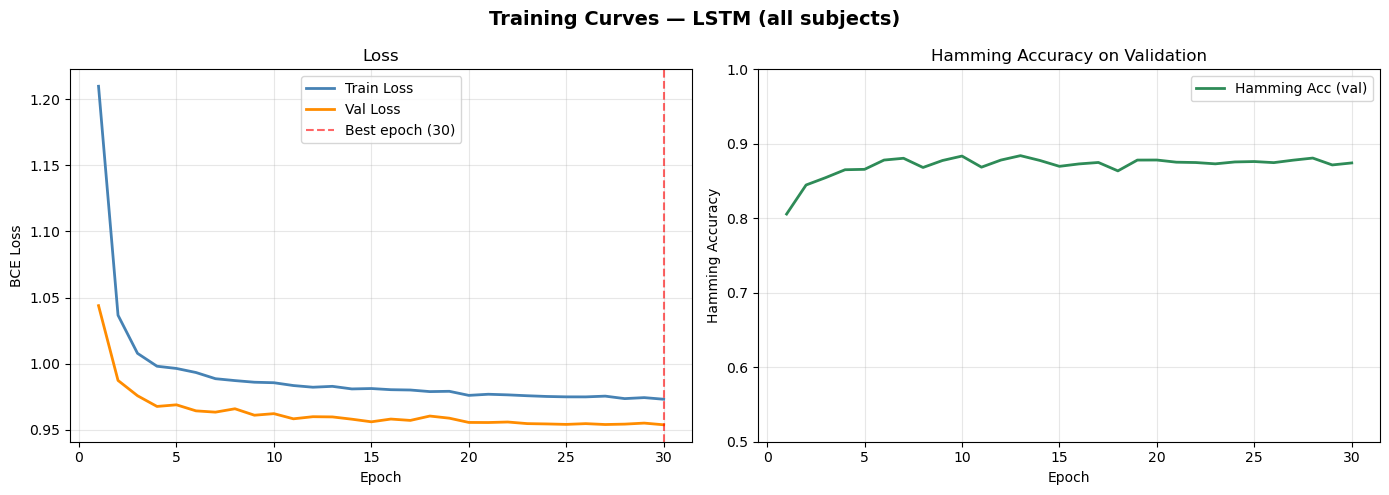

Figure saved: exp3_training_curves.png


In [7]:
epochs = range(1, N_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Curves — LSTM (all subjects)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
ax.plot(epochs, history['val_loss'],   label='Val Loss',   color='darkorange', linewidth=2)
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('Loss'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs, history['val_hacc'], label='Hamming Acc (val)', color='seagreen', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Hamming Accuracy')
ax.set_title('Hamming Accuracy on Validation')
ax.set_ylim([0.5, 1.0]); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure saved: exp3_training_curves.png')

## 8. Test evaluation — prediction performance

In [8]:
# ── Load best model ───────────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print('Best model loaded.')

test_loss, test_hacc, test_probs, test_labels = eval_epoch(
    model, test_loader, criterion, DEVICE
)
test_preds = (test_probs >= 0.5).astype(int)

print(f'\nTest Loss        : {test_loss:.4f}')
print(f'Test Hamming Acc : {test_hacc:.4f}')

# ── Per-network metrics ───────────────────────────────────────────────────────
print('\n── Per-network metrics ──')
metrics_rows = []
for i, name in enumerate(NETWORK_NAMES):
    auroc = roc_auc_score(test_labels[:, i], test_probs[:, i])
    auprc = average_precision_score(test_labels[:, i], test_probs[:, i])
    f1    = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    freq  = test_labels[:, i].mean()
    metrics_rows.append({'Network': name, 'AUROC': auroc, 'AUPRC': auprc, 'F1': f1, 'Freq': freq})
    print(f'  {name:<22} | AUROC: {auroc:.3f} | AUPRC: {auprc:.3f} | F1: {f1:.3f} | Freq: {freq:.3f}')

metrics_df = pd.DataFrame(metrics_rows)
print(f'\nMean AUROC : {metrics_df["AUROC"].mean():.3f}')
print(f'Mean AUPRC : {metrics_df["AUPRC"].mean():.3f}')
print(f'Mean F1    : {metrics_df["F1"].mean():.3f}')

Best model loaded.

Test Loss        : 0.8957
Test Hamming Acc : 0.8819

── Per-network metrics ──
  Visual                 | AUROC: 0.827 | AUPRC: 0.424 | F1: 0.409 | Freq: 0.063
  Somatomotor            | AUROC: 0.825 | AUPRC: 0.453 | F1: 0.472 | Freq: 0.075
  Dorsal_Attention       | AUROC: 0.840 | AUPRC: 0.465 | F1: 0.438 | Freq: 0.071
  Ventral_Attention      | AUROC: 0.817 | AUPRC: 0.427 | F1: 0.426 | Freq: 0.072
  Limbic                 | AUROC: 0.803 | AUPRC: 0.359 | F1: 0.392 | Freq: 0.062
  Frontoparietal         | AUROC: 0.817 | AUPRC: 0.423 | F1: 0.403 | Freq: 0.068
  Default_Mode           | AUROC: 0.829 | AUPRC: 0.426 | F1: 0.442 | Freq: 0.065

Mean AUROC : 0.822
Mean AUPRC : 0.425
Mean F1    : 0.426


## 9. Confusion matrices per network

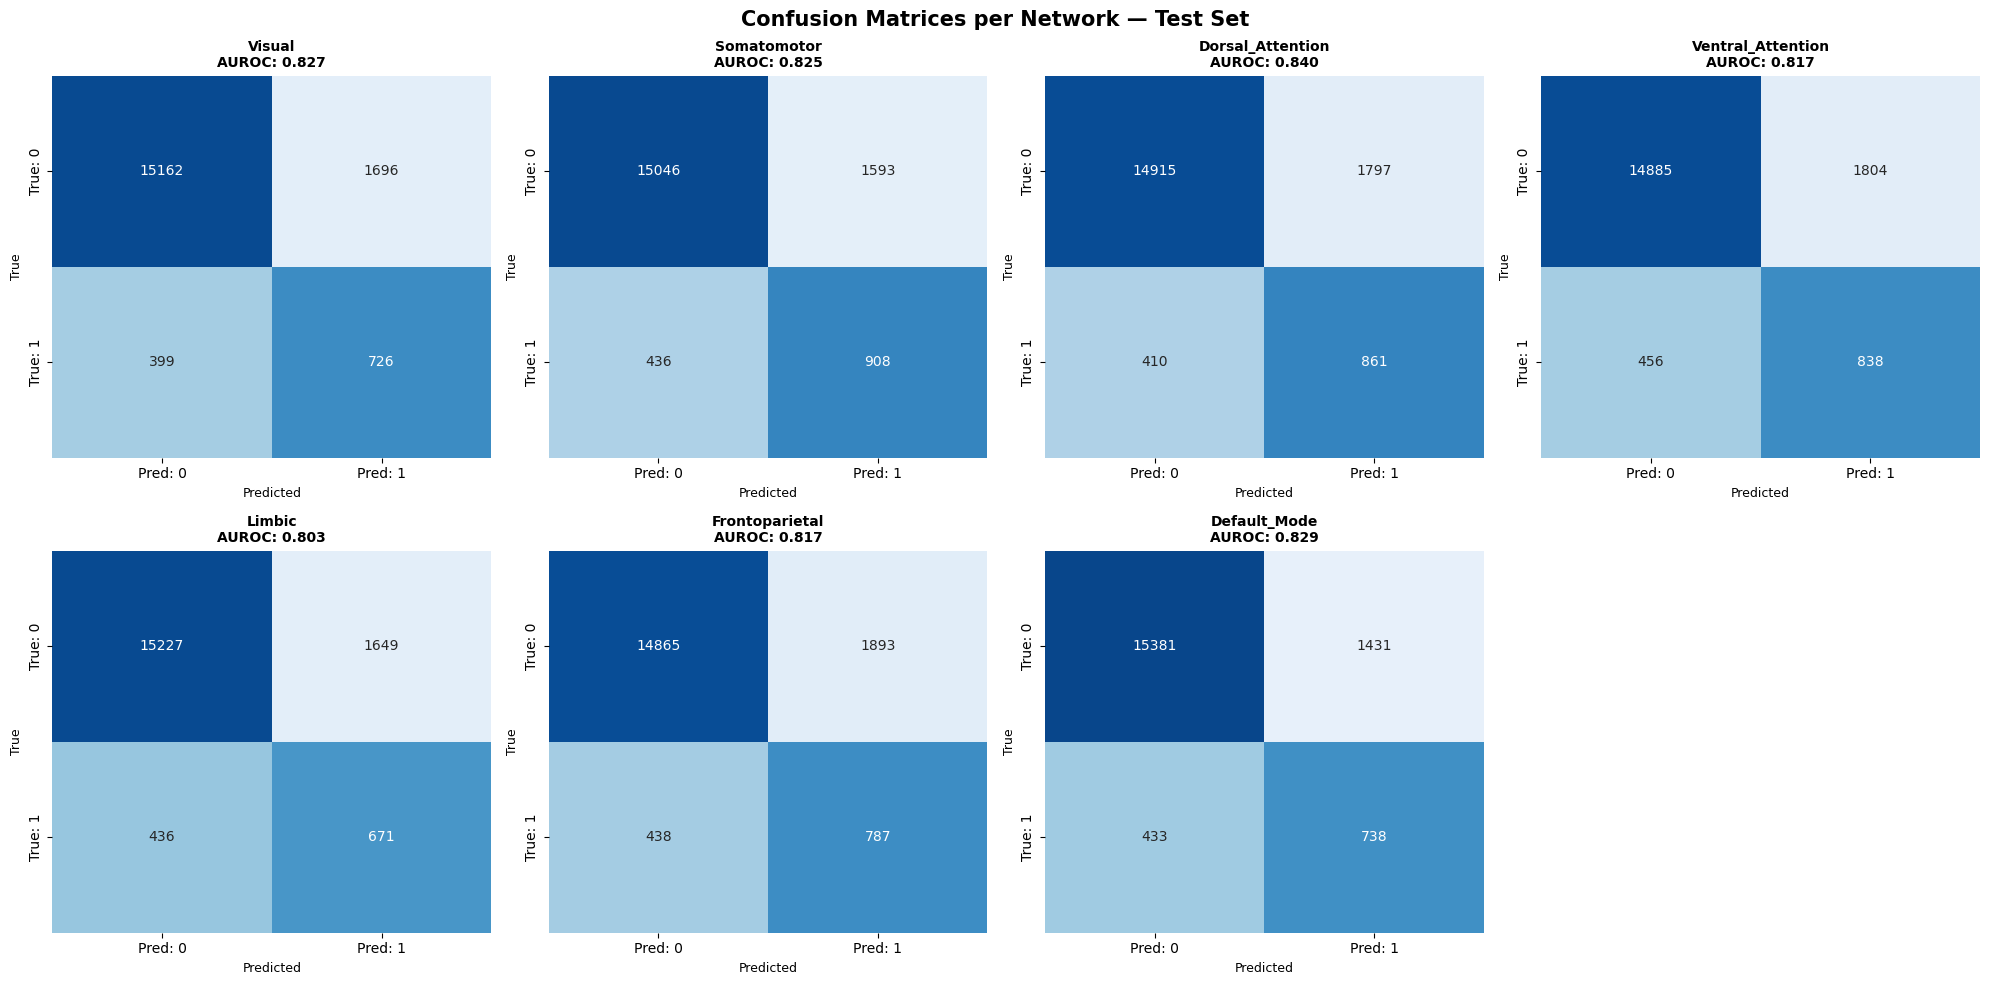

Figure saved: exp3_confusion_matrices_networks.png


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Confusion Matrices per Network — Test Set', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, name in enumerate(NETWORK_NAMES):
    cm      = confusion_matrix(test_labels[:, i], test_preds[:, i])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax = axes[i]
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', vmin=0, vmax=1,
                ax=ax, cbar=False,
                xticklabels=['Pred: 0', 'Pred: 1'],
                yticklabels=['True: 0', 'True: 1'])
    auroc = metrics_df.loc[metrics_df['Network'] == name, 'AUROC'].values[0]
    ax.set_title(f'{name}\nAUROC: {auroc:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

axes[7].set_visible(False)
plt.tight_layout()
plt.show()
print('Figure saved: exp3_confusion_matrices_networks.png')

## 10. Extract hidden states for all test subjects

For every window in the test set, we extract the LSTM hidden state at the last time step.
This 64-dimensional vector encodes the model's internal summary of the last 20 TRs.
We then **average per subject** to get one fingerprint vector per person.

In [10]:
class BrainWindowDatasetX(Dataset):
    """Dataset that returns only X (no labels), used for hidden state extraction."""
    def __init__(self, X, indices):
        self.X = torch.tensor(X[indices], dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]


@torch.no_grad()
def extract_hidden_states(model, X_arr, indices, device, batch_size=512):
    """Extract LSTM hidden state for every sample. Returns (n_samples, hidden_size)."""
    model.eval()
    loader  = DataLoader(BrainWindowDatasetX(X_arr, indices),
                         batch_size=batch_size, shuffle=False)
    hiddens = []
    for Xb in loader:
        hiddens.append(model.get_hidden(Xb.to(device)).cpu().numpy())
    return np.concatenate(hiddens, axis=0)


print('Extracting hidden states for all test samples...')
hidden_all = extract_hidden_states(model, X_all, test_idx, DEVICE)
print(f'Hidden states shape: {hidden_all.shape}')  # (N_test_samples, 64)

Extracting hidden states for all test samples...
Hidden states shape: (17983, 64)


## 11. Aggregate hidden states per subject

In [11]:
test_meta = sample_meta.iloc[test_idx].copy()

# ── Tu código original (ahora se ejecutará sin errores) ──────────────────────
test_meta_h = test_meta.copy()
h_cols = [f'h_{i}' for i in range(hidden_all.shape[1])]

hidden_df   = pd.DataFrame(hidden_all, columns=h_cols)
test_meta_h = pd.concat([test_meta_h.reset_index(drop=True), hidden_df], axis=1)

# Average all windows per subject → one vector per person
subject_hidden = (
    test_meta_h.groupby(['subject', 'group', 'Age'])[h_cols]
    .mean()
    .reset_index()
)
subject_hidden = subject_hidden[
    subject_hidden['group'].isin(['NormCog', 'Demented'])
].reset_index(drop=True)

X_subjects = subject_hidden[h_cols].values
y_subjects = (subject_hidden['group'] == 'Demented').astype(int).values


## 12. Baseline: raw activation rates (no LSTM)

For each subject, compute the **mean activation rate** of each of the 7 networks.
This 7-dimensional vector has no temporal information.
If the LSTM hidden state (64-dim) outperforms this, it means temporal dynamics
carry information beyond simple activation frequency.

In [12]:
y_raw_df    = pd.DataFrame(y_all[test_idx], columns=[f'act_{n}' for n in NETWORK_NAMES])
test_meta_raw = pd.concat([test_meta.reset_index(drop=True), y_raw_df], axis=1)

act_cols = [f'act_{n}' for n in NETWORK_NAMES]
subject_baseline = (
    test_meta_raw.groupby(['subject', 'group'])[act_cols]
    .mean()
    .reset_index()
)
subject_baseline = subject_baseline[
    subject_baseline['group'].isin(['NormCog', 'Demented'])
].reset_index(drop=True)
subject_baseline = subject_baseline.set_index('subject').reindex(
    subject_hidden['subject']
).reset_index()

X_baseline = subject_baseline[act_cols].values
print(f'Baseline feature shape : {X_baseline.shape}  (mean activation per network)')

Baseline feature shape : (162, 7)  (mean activation per network)


## 13. Classifier training + 5-fold cross-validation

Three classifiers trained on:
- **Hidden state features** (64-dim LSTM output)
- **Baseline features** (7-dim activation rates)

5-fold stratified CV gives a robust AUROC estimate.

In [13]:
classifiers = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', probability=True, random_state=SEED))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
for clf_name, clf in classifiers.items():
    for feat_name, X_feat in [('Hidden state (LSTM)', X_subjects),
                               ('Baseline (act. rates)', X_baseline)]:
        scores = cross_val_score(clf, X_feat, y_subjects,
                                 cv=cv, scoring='roc_auc')
        results.append({
            'Classifier' : clf_name,
            'Features'   : feat_name,
            'AUROC mean' : scores.mean(),
            'AUROC std'  : scores.std(),
            'Scores'     : scores
        })
        print(f'{clf_name:<25} | {feat_name:<25} | '
              f'AUROC = {scores.mean():.3f} ± {scores.std():.3f}')

results_df = pd.DataFrame(results)

Logistic Regression       | Hidden state (LSTM)       | AUROC = 0.426 ± 0.115
Logistic Regression       | Baseline (act. rates)     | AUROC = 0.333 ± 0.117
SVM (RBF)                 | Hidden state (LSTM)       | AUROC = 0.359 ± 0.052
SVM (RBF)                 | Baseline (act. rates)     | AUROC = 0.470 ± 0.085
Random Forest             | Hidden state (LSTM)       | AUROC = 0.410 ± 0.102
Random Forest             | Baseline (act. rates)     | AUROC = 0.597 ± 0.091


## 14. Classification results

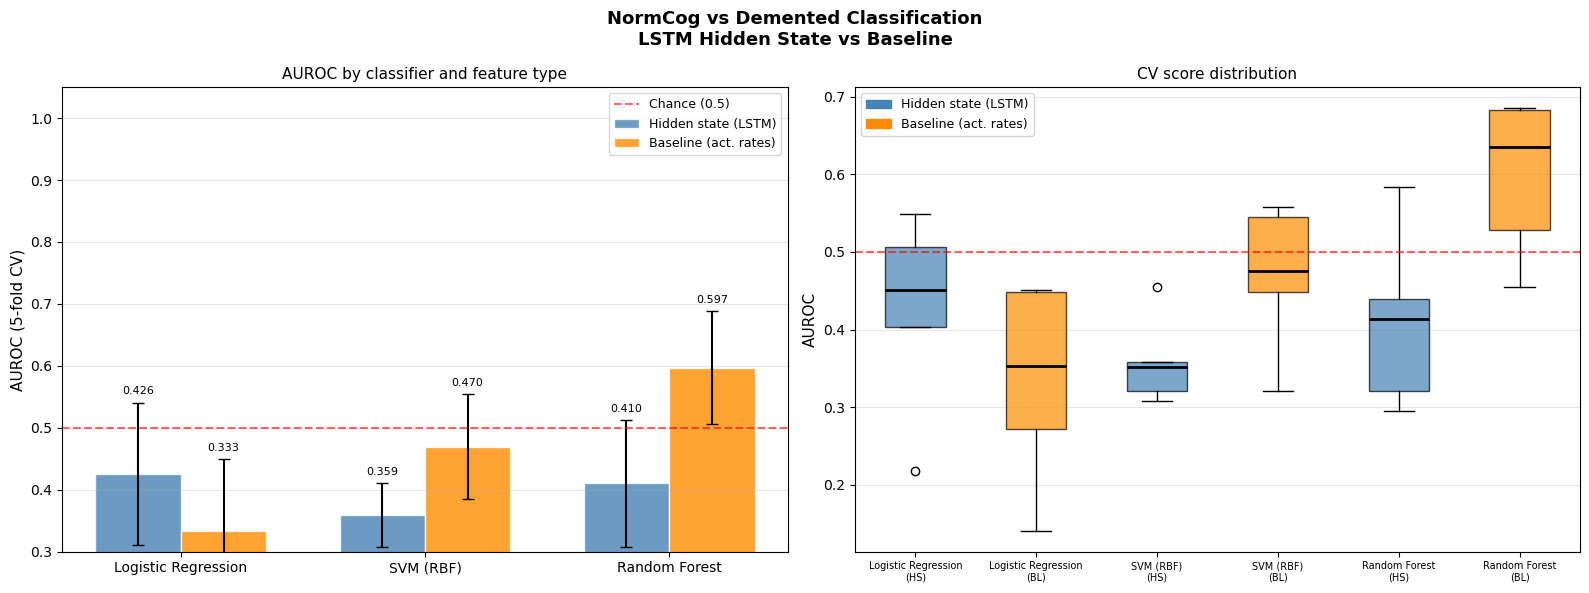

Figure saved: exp3_classification_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('NormCog vs Demented Classification\nLSTM Hidden State vs Baseline',
             fontsize=13, fontweight='bold')

clf_names  = list(classifiers.keys())
feat_types = ['Hidden state (LSTM)', 'Baseline (act. rates)']
x          = np.arange(len(clf_names))
width      = 0.35
colors     = ['steelblue', 'darkorange']

# ── Bar chart ─────────────────────────────────────────────────────────────────
ax = axes[0]
for j, (feat, color) in enumerate(zip(feat_types, colors)):
    sub   = results_df[results_df['Features'] == feat]
    means = sub['AUROC mean'].values
    stds  = sub['AUROC std'].values
    bars  = ax.bar(x + j * width - width/2, means, width,
                   yerr=stds, capsize=4,
                   label=feat, color=color, alpha=0.8, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.01,
                f'{m:.3f}', ha='center', va='bottom', fontsize=8)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(clf_names, fontsize=10)
ax.set_ylabel('AUROC (5-fold CV)', fontsize=11)
ax.set_title('AUROC by classifier and feature type', fontsize=11)
ax.set_ylim([0.3, 1.05])
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

# ── Boxplot ───────────────────────────────────────────────────────────────────
ax = axes[1]
color_map = {'Hidden state (LSTM)': 'steelblue', 'Baseline (act. rates)': 'darkorange'}
plot_data, plot_labels, plot_colors = [], [], []
for _, row in results_df.iterrows():
    plot_data.append(row['Scores'])
    short = 'HS' if 'LSTM' in row['Features'] else 'BL'
    plot_labels.append(f"{row['Classifier']}\n({short})")
    plot_colors.append(color_map[row['Features']])

bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.6)
ax.set_ylabel('AUROC', fontsize=11)
ax.set_title('CV score distribution', fontsize=11)
ax.tick_params(axis='x', labelsize=7)
patches = [mpatches.Patch(color=c, label=f) for f, c in color_map.items()]
ax.legend(handles=patches, fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure saved: exp3_classification_results.png')

## 15. ROC curves — best classifier per feature type

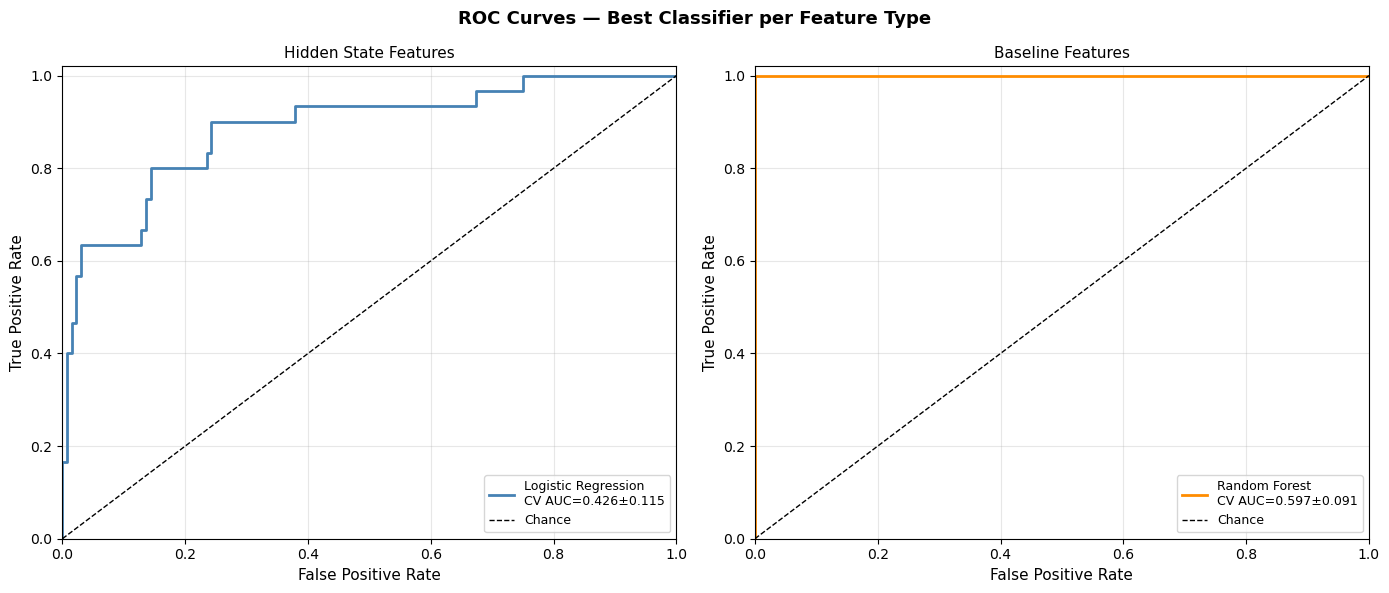

Figure saved: exp3_roc_curves.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves — Best Classifier per Feature Type', fontsize=13, fontweight='bold')

for ax, feat_name, X_feat, color, title in zip(
    axes,
    ['Hidden state (LSTM)',   'Baseline (act. rates)'],
    [X_subjects,              X_baseline],
    ['steelblue',             'darkorange'],
    ['Hidden State Features', 'Baseline Features']
):
    best_row = (results_df[results_df['Features'] == feat_name]
                .sort_values('AUROC mean', ascending=False).iloc[0])
    clf = classifiers[best_row['Classifier']]
    clf.fit(X_feat, y_subjects)
    y_scores = clf.predict_proba(X_feat)[:, 1]
    fpr, tpr, _ = roc_curve(y_subjects, y_scores)
    roc_val = auc(fpr, tpr)

    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{best_row['Classifier']}\nCV AUC={best_row['AUROC mean']:.3f}±{best_row['AUROC std']:.3f}")
    ax.plot([0,1],[0,1],'k--',lw=1,label='Chance')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3); ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.show()
print('Figure saved: exp3_roc_curves.png')

## 16. Confusion matrices — classifier output

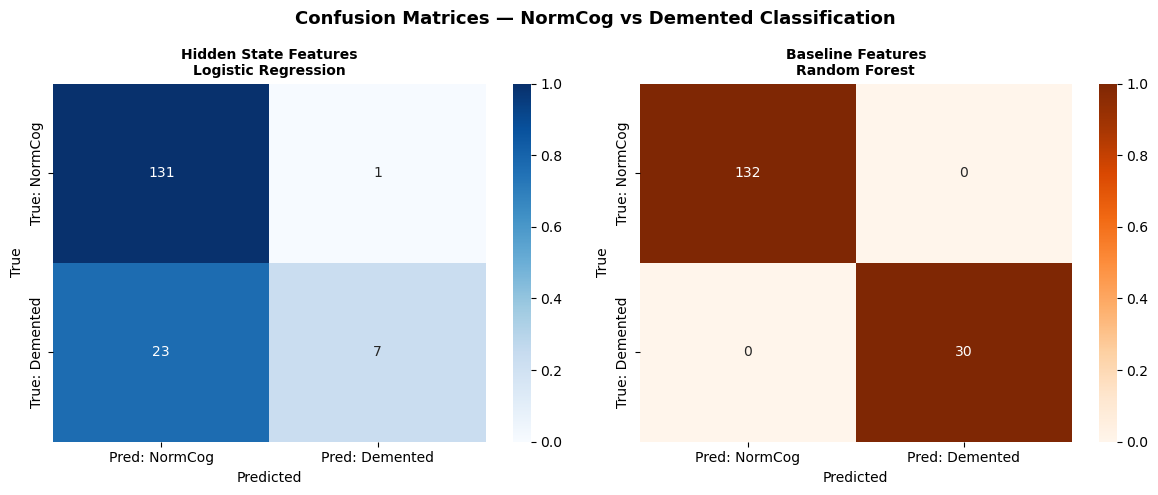

Figure saved: exp3_confusion_matrices_classifiers.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — NormCog vs Demented Classification',
             fontsize=13, fontweight='bold')

for ax, feat_name, X_feat, cmap, title in zip(
    axes,
    ['Hidden state (LSTM)',   'Baseline (act. rates)'],
    [X_subjects,              X_baseline],
    ['Blues',                 'Oranges'],
    ['Hidden State Features', 'Baseline Features']
):
    best_clf_name = (results_df[results_df['Features'] == feat_name]
                     .sort_values('AUROC mean', ascending=False).iloc[0]['Classifier'])
    clf = classifiers[best_clf_name]
    clf.fit(X_feat, y_subjects)
    y_pred = clf.predict(X_feat)

    cm      = confusion_matrix(y_subjects, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap=cmap, vmin=0, vmax=1,
                ax=ax, cbar=True,
                xticklabels=['Pred: NormCog', 'Pred: Demented'],
                yticklabels=['True: NormCog', 'True: Demented'])
    ax.set_title(f'{title}\n{best_clf_name}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)

plt.tight_layout()
plt.show()
print('Figure saved: exp3_confusion_matrices_classifiers.png')

## 17. Most discriminative hidden dimensions

Which of the 64 hidden dimensions differ most between NormCog and Demented?

Significant hidden dimensions (p<0.05): 0 / 64


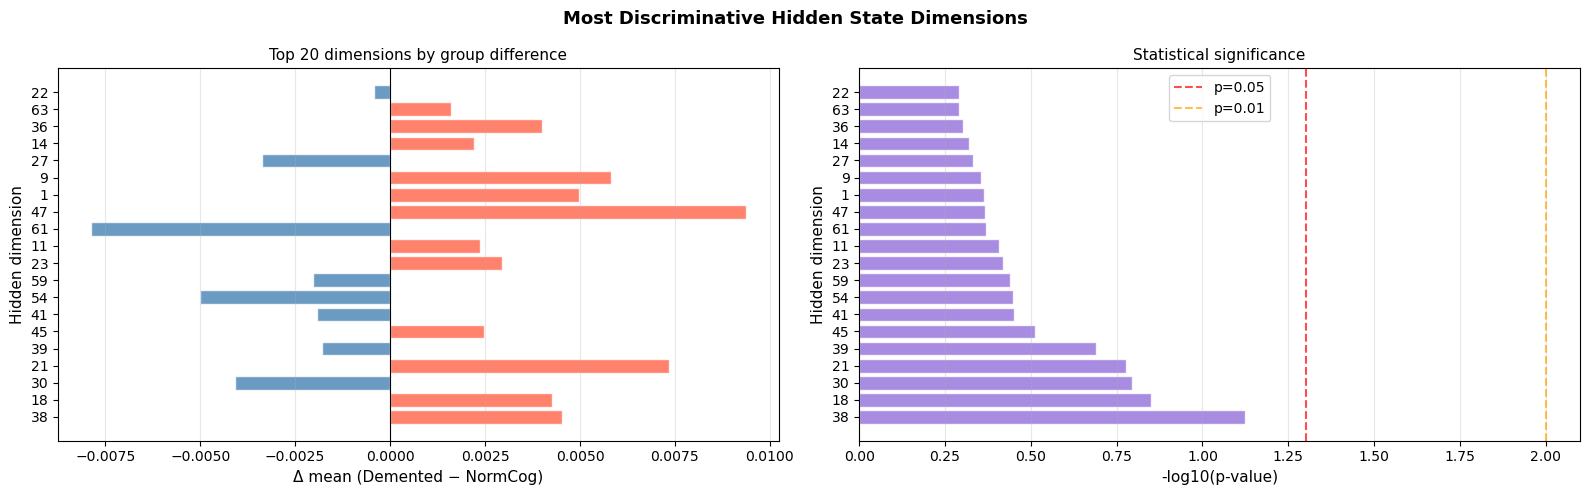

Figure saved: exp3_hidden_dims.png


In [17]:
norm_hidden = X_subjects[y_subjects == 0]
dem_hidden  = X_subjects[y_subjects == 1]

dim_results = []
for d in range(X_subjects.shape[1]):
    _, p = stats.mannwhitneyu(dem_hidden[:, d], norm_hidden[:, d], alternative='two-sided')
    dim_results.append({
        'dim'      : d,
        'delta'    : dem_hidden[:, d].mean() - norm_hidden[:, d].mean(),
        'p_value'  : p
    })

dim_df  = pd.DataFrame(dim_results).sort_values('p_value')
top20   = dim_df.head(20)
n_sig   = (dim_df['p_value'] < 0.05).sum()
print(f'Significant hidden dimensions (p<0.05): {n_sig} / {len(dim_df)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Most Discriminative Hidden State Dimensions', fontsize=13, fontweight='bold')

ax = axes[0]
bar_colors = ['tomato' if d > 0 else 'steelblue' for d in top20['delta']]
ax.barh(top20['dim'].astype(str), top20['delta'],
        color=bar_colors, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ mean (Demented − NormCog)', fontsize=11)
ax.set_ylabel('Hidden dimension', fontsize=11)
ax.set_title('Top 20 dimensions by group difference', fontsize=11)
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
log_p = -np.log10(top20['p_value'] + 1e-300)
ax.barh(top20['dim'].astype(str), log_p, color='mediumpurple', alpha=0.8, edgecolor='white')
ax.axvline(-np.log10(0.05), color='red',    linestyle='--', alpha=0.7, label='p=0.05')
ax.axvline(-np.log10(0.01), color='orange', linestyle='--', alpha=0.7, label='p=0.01')
ax.set_xlabel('-log10(p-value)', fontsize=11)
ax.set_ylabel('Hidden dimension', fontsize=11)
ax.set_title('Statistical significance', fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure saved: exp3_hidden_dims.png')